In [ ]:
import os

# 環境変数設定
import numpy as np
import warnings
import tifffile
import cv2

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm

PATH_OUTPUT = os.path.join('output', '601')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [41]:
# chirp信号の生成
def phase_(t, f0, f_doppler):
    return 2 * np.pi * (f0 * t + 0.5 * f_doppler * t ** 2)

def chirp_(t, f0, f_doppler):
    return np.exp(1j * phase_(t, f0, f_doppler))

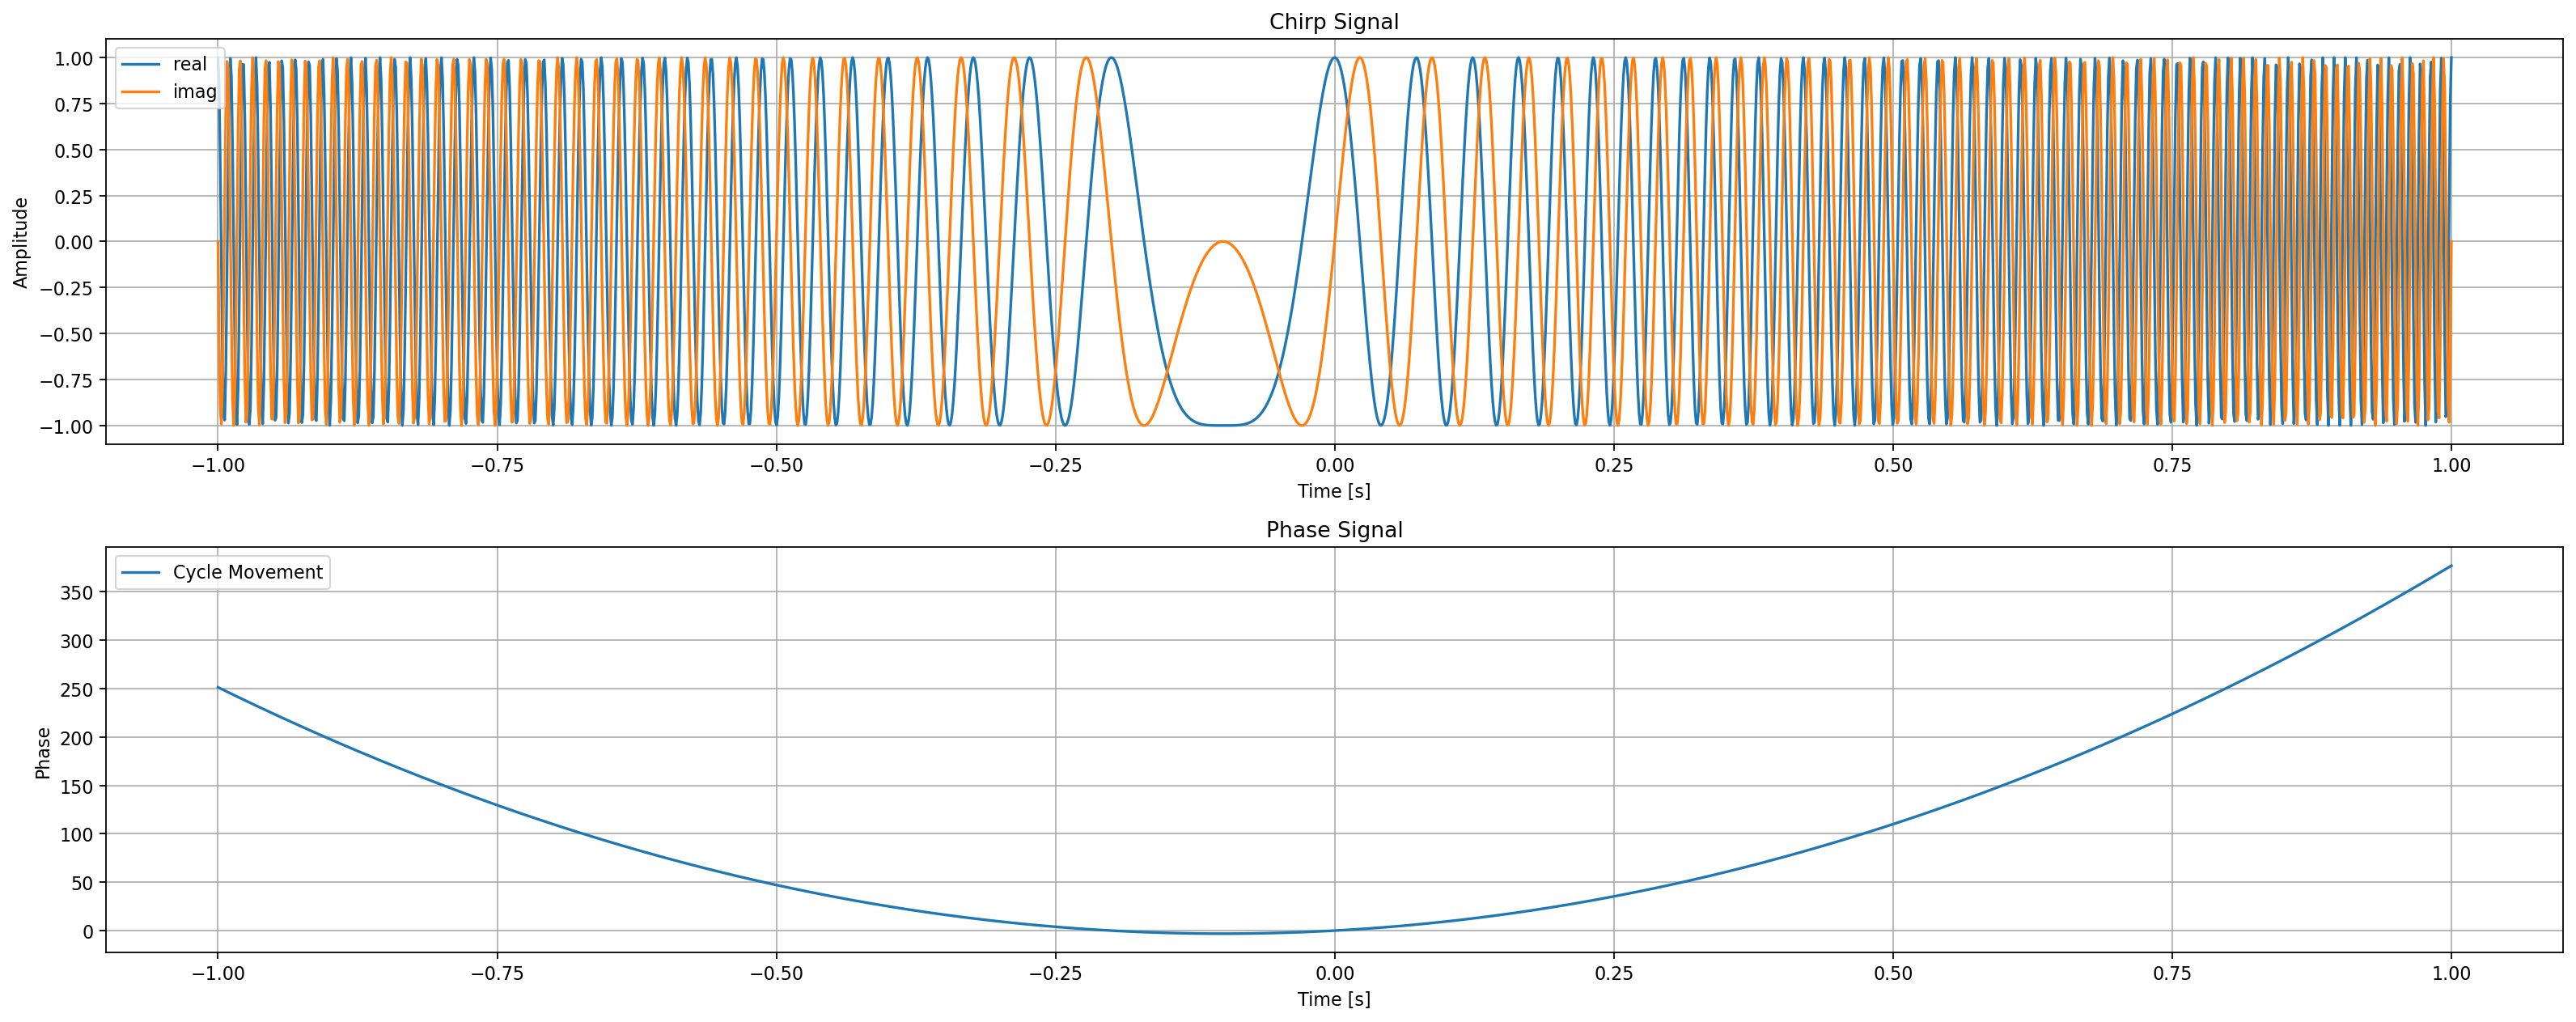

In [109]:
NUM_SAMPLE = 2000
FREQ_CENTER = 10
FREQ_DOPPLER = 100

t_sample = np.linspace(-1, 1, NUM_SAMPLE)
chirp_signal = chirp_(t_sample, FREQ_CENTER, FREQ_DOPPLER)
phase_signal = phase_(t_sample, FREQ_CENTER, FREQ_DOPPLER)

# plot
plt.figure(figsize=(20, 8), facecolor='w', edgecolor='k', dpi=160)
plt.subplot(211)
plt.plot(t_sample, np.real(chirp_signal), label='real')
plt.plot(t_sample, np.imag(chirp_signal), label='imag')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title('Chirp Signal')

plt.subplot(212)
plt.plot(t_sample, phase_signal, label='Cycle Movement')
plt.xlabel('Time [s]')
plt.ylabel('Phase')
plt.grid()
plt.title('Phase Signal')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'phase_signal.png'))
plt.show();plt.clf();plt.close();

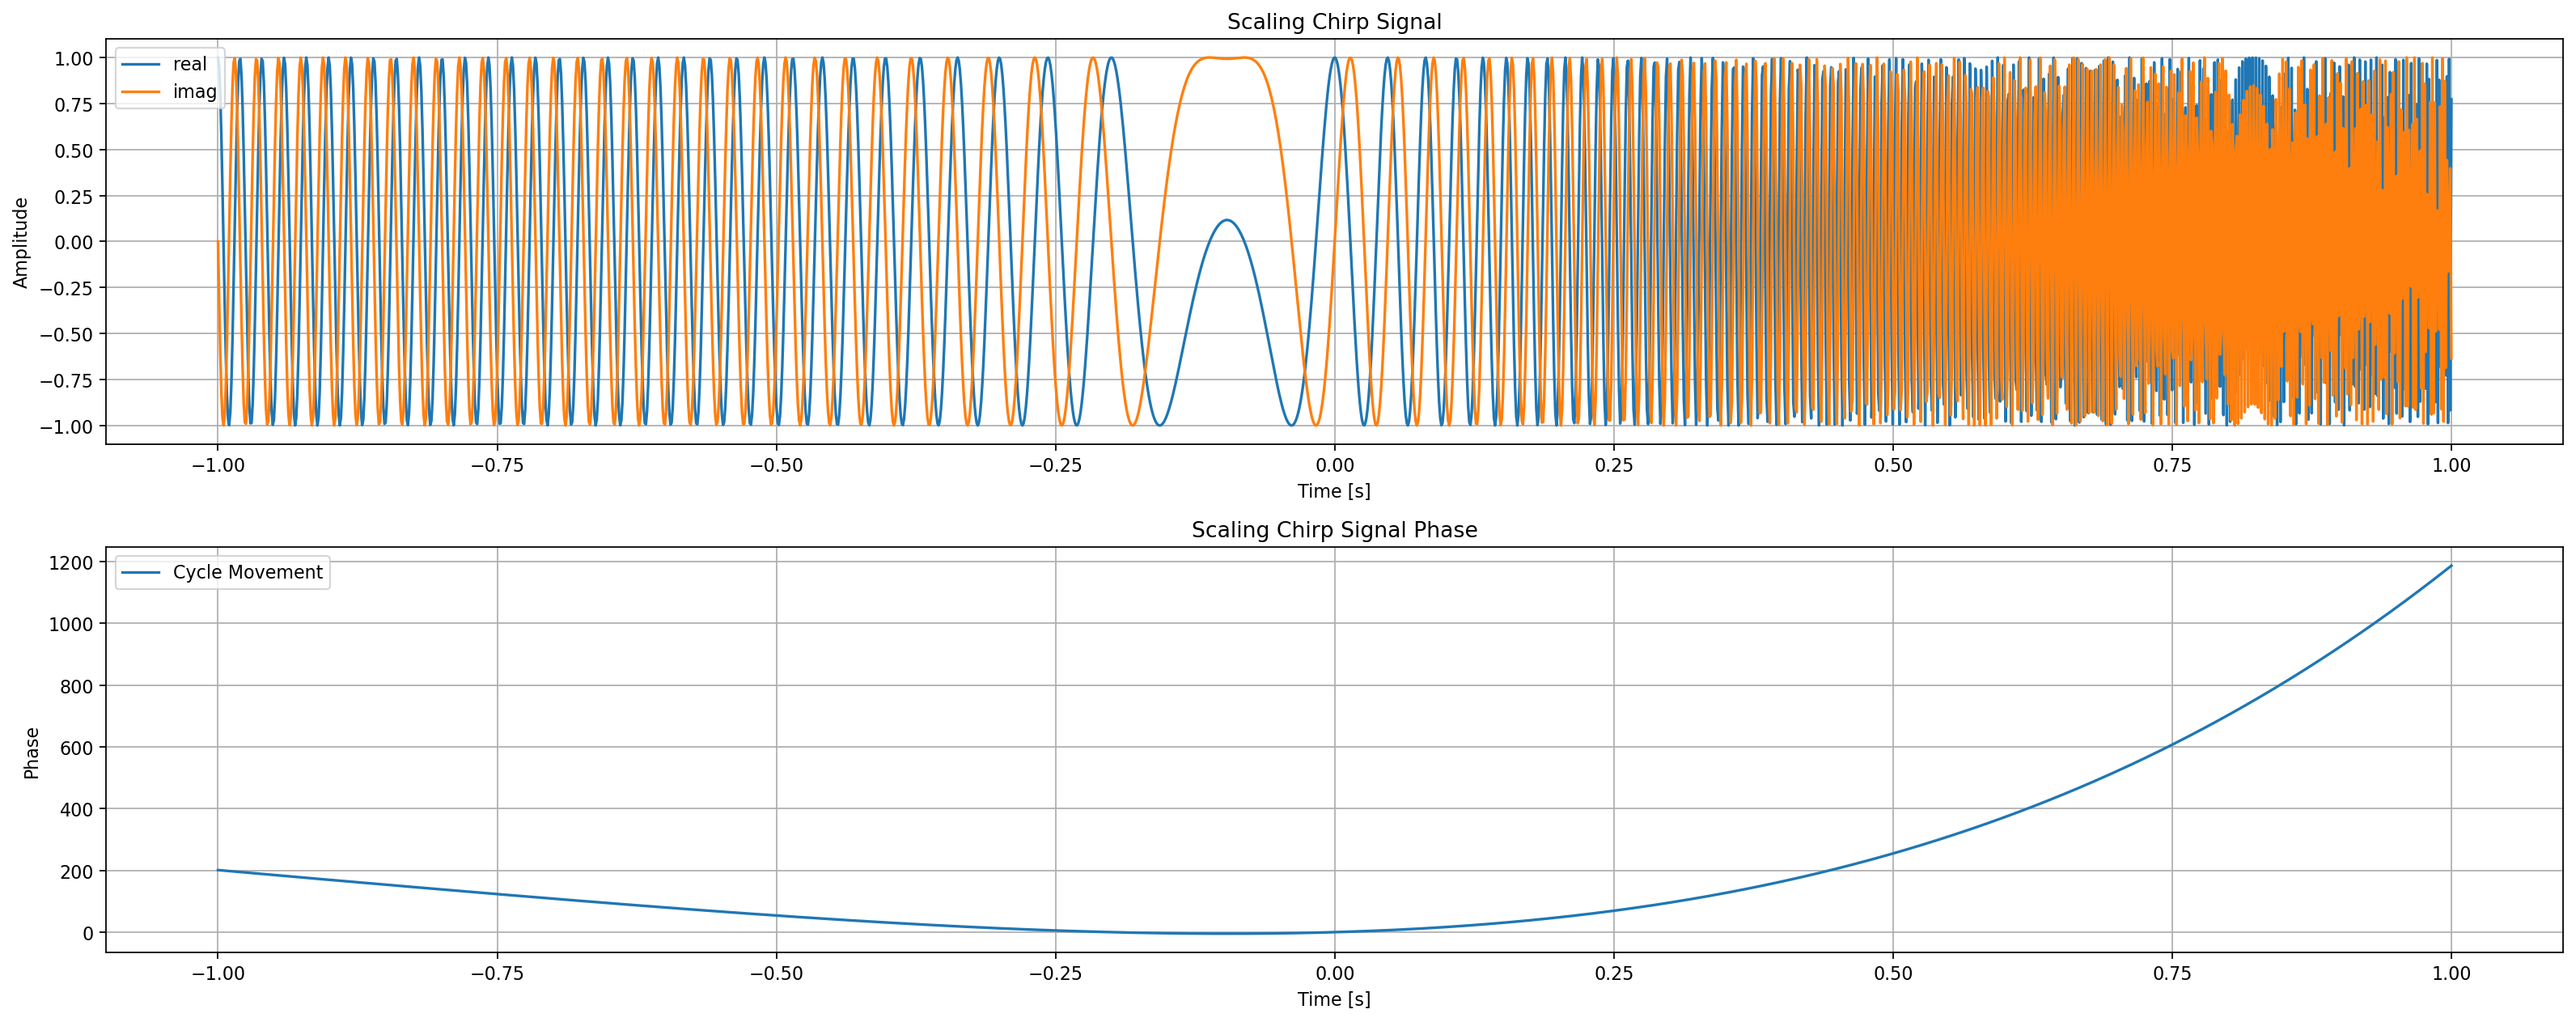

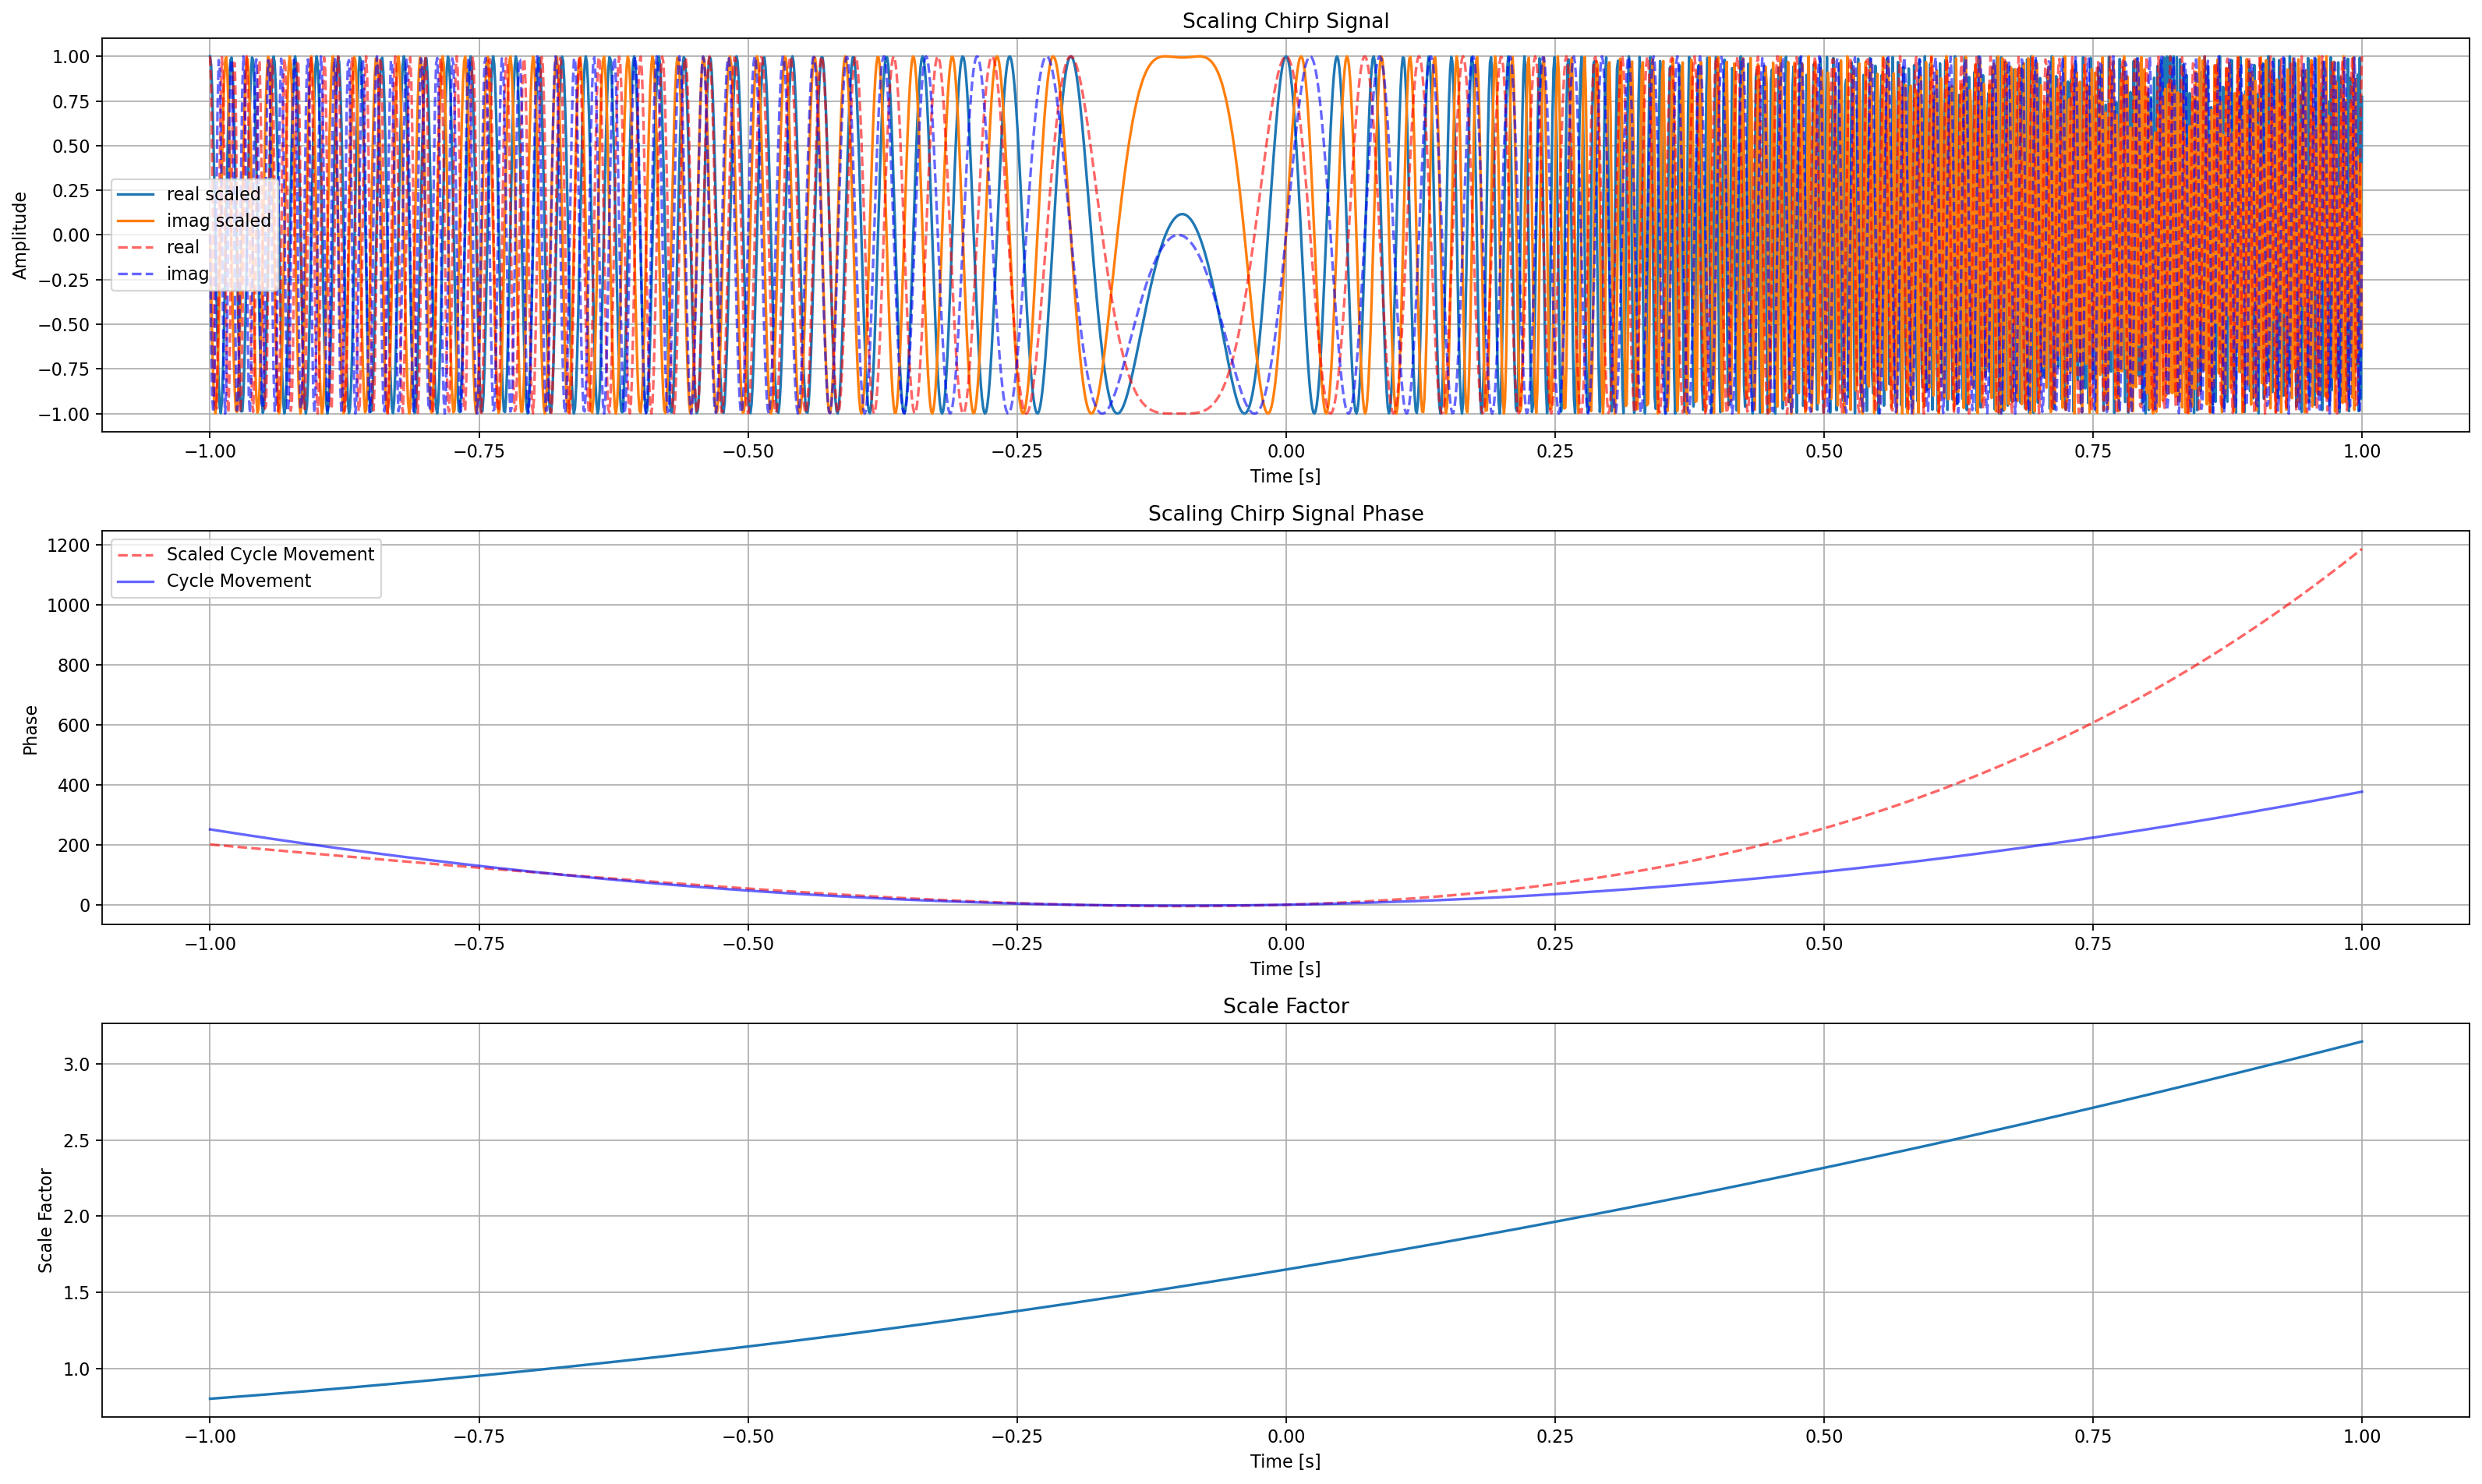

In [108]:
def chirp_scaling_phase(t, f0, f_doppler, alpha=1.01, beta=1.1, gamma=1):
    # example scale; paper scaling is quadratic only
    t_v = np.arange(0, 1, 1/len(t)) 
    scaling_factor = alpha * t_v** 2 + beta * t_v + gamma
    phase = phase_(t, f0, f_doppler)
    return phase * scaling_factor, scaling_factor

def chirp_scaling(t, f0, f_doppler, alpha=1e-1, beta=1, gamma=20):
    phase, _ =  chirp_scaling_phase(t, f0, f_doppler, alpha, beta, gamma)
    return np.exp(1j * phase)

APLHA, BETA, GAMMA =  1.3, 1.05, 0.8
chirp_scaled = chirp_scaling(t_sample, FREQ_CENTER, FREQ_DOPPLER, APLHA, BETA, GAMMA)
phase_scaled, scale_factor = chirp_scaling_phase(
    t_sample, FREQ_CENTER ,FREQ_DOPPLER, APLHA, BETA, GAMMA)

# plot
plt.figure(figsize=(20, 8), facecolor='w', edgecolor='k', dpi=160)
plt.subplot(211)
plt.plot(t_sample, np.real(chirp_scaled), label='real')
plt.plot(t_sample, np.imag(chirp_scaled), label='imag')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title(f'Scaling Chirp Signal')

plt.subplot(212)
plt.plot(t_sample, phase_scaled, label='Cycle Movement')
plt.xlabel('Time [s]')
plt.ylabel('Phase')
plt.grid()
plt.title(f'Scaling Chirp Signal Phase')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'phase_signal_scaled.png'))
plt.show();plt.clf();plt.close();

# prepare plot
plt.figure(figsize=(20, 12), facecolor='w', edgecolor='k', dpi=160)
plt.subplot(311)
plt.plot(t_sample, np.real(chirp_scaled), label='real scaled')
plt.plot(t_sample, np.imag(chirp_scaled), label='imag scaled')
plt.plot(t_sample, np.real(chirp_signal), label='real', color='r', linestyle='--', alpha=0.6)
plt.plot(t_sample, np.imag(chirp_signal), label='imag', color='b', linestyle='--', alpha=0.6)

plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title(f'Scaling Chirp Signal')

plt.subplot(312)
plt.plot(t_sample, phase_scaled, label='Scaled Cycle Movement', color='r', linestyle='--', alpha=0.6)
plt.plot(t_sample, phase_signal, label='Cycle Movement', color='b', alpha=0.6)
plt.xlabel('Time [s]')
plt.ylabel('Phase')
plt.grid()
plt.title(f'Scaling Chirp Signal Phase')
plt.legend()

plt.subplot(313)
plt.plot(t_sample, scale_factor, label='Scaling Factor')
plt.xlabel('Time [s]')
plt.ylabel('Scale Factor')
plt.grid()
plt.title(f'Scale Factor')

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'phase_signal_scaled_vs_no-scaling.png'))
plt.show();plt.clf();plt.close();